In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [12]:
# XOR 데이터
X = torch.tensor([[0.,0],[0,1],[1,0],[1,1]])
y = torch.tensor([[0.],[1.],[1.],[0.]])

# hidden - ReLu, output - sigmoid 
def make_model(n_hidden_layers, nodes=4):
    layers = [nn.Linear(2, nodes), nn.ReLU()]
    for _ in range(n_hidden_layers - 1):
        layers += [nn.Linear(nodes, nodes), nn.ReLU()]
    layers += [nn.Linear(nodes, 1), nn.Sigmoid()]
    return nn.Sequential(*layers)

def train(model, epochs=10000, lr=0.05):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    loss_history = []
 
    for epoch in range(epochs):
        pred = model(X)
        loss = criterion(pred, y)
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        loss_history.append(loss.item())
 
    return loss_history

torch.manual_seed(1)
model_2  = make_model(n_hidden_layers=2)
loss_2   = train(model_2)
 
torch.manual_seed(1)
model_10 = make_model(n_hidden_layers=10)
loss_10  = train(model_10)
 

## 결과
- 2-layer : Accuracy 100%
- 10-layer : Accuracy 50%
    - 학습이 안되었으며(train loss 일정), 모든 출력이 0.5로 랜덤 출력값임

In [13]:
def evaluate(model, name):
    model.eval()
    with torch.no_grad():
        preds = model(X)
        pred_labels = preds.round()
        acc = (pred_labels == y).float().mean().item() * 100
 
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"{'Input':>10} | {'Target':>6} | {'Output':>8} | {'Pred':>5}")
    print("-" * 40)
    for i in range(4):
        x_str = f"({int(X[i,0])}, {int(X[i,1])})"
        print(f"{x_str:>10} | {int(y[i,0]):>6} | {preds[i,0].item():>8.4f} | {int(pred_labels[i,0]):>5}")
    print(f"\n  Accuracy: {acc:.1f}%")
    return acc
 
acc_2  = evaluate(model_2,  "2-layer  Hidden Network")
acc_10 = evaluate(model_10, "10-layer Hidden Network")


  2-layer  Hidden Network
     Input | Target |   Output |  Pred
----------------------------------------
    (0, 0) |      0 |   0.0000 |     0
    (0, 1) |      1 |   1.0000 |     1
    (1, 0) |      1 |   1.0000 |     1
    (1, 1) |      0 |   0.0000 |     0

  Accuracy: 100.0%

  10-layer Hidden Network
     Input | Target |   Output |  Pred
----------------------------------------
    (0, 0) |      0 |   0.5000 |     0
    (0, 1) |      1 |   0.5000 |     0
    (1, 0) |      1 |   0.5000 |     0
    (1, 1) |      0 |   0.5000 |     0

  Accuracy: 50.0%


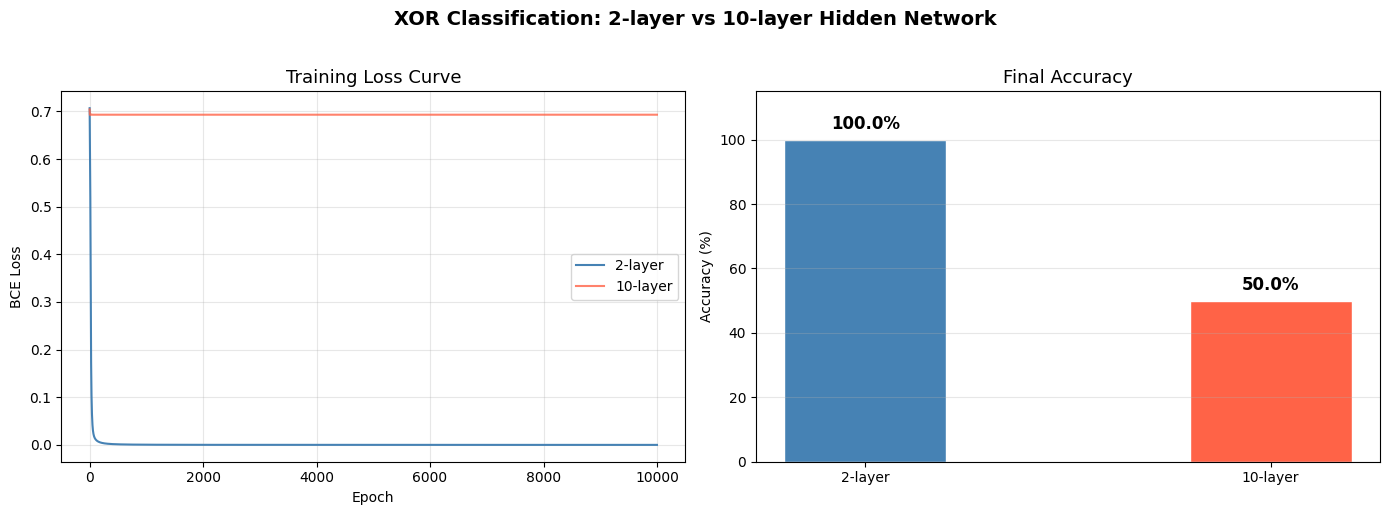

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# (1) Loss Curve
axes[0].plot(loss_2,  label='2-layer',  color='steelblue', linewidth=1.5)
axes[0].plot(loss_10, label='10-layer', color='tomato',    linewidth=1.5, alpha=0.8)
axes[0].set_title('Training Loss Curve', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
# (2) Accuracy Bar
models_name = ['2-layer', '10-layer']
accs = [acc_2, acc_10]
colors = ['steelblue', 'tomato']
bars = axes[1].bar(models_name, accs, color=colors, width=0.4, edgecolor='white')
axes[1].set_title('Final Accuracy', fontsize=13)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 115)
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
 
plt.suptitle('XOR Classification: 2-layer vs 10-layer Hidden Network',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 설명

- XOR은 단순한 비선형 문제로, hidden layer 2개와 node 4개로 결정 경계를 충분히 표현할 수 있다. 
    - 즉, 2-layer로 설정 시 모델 복잡도가 문제에 적합하다. 
    - 10-layer의 경우 역전파 시 vanishing gradient 문제가 발생하여 학습이 제대로 이루어지지 않았다. 
- 모델의 깊이는 깊을수록 무조건 좋은 것이 아니라, 문제의 복잡도에 맞게 설계되어야 한다.